# Przygotowanie danych do modelowania (Sprint 2)

**Projekt zaliczeniowy — kurs Data Science, grupa jdszr24-2**

Notebook realizuje zadania Sprintu 2 z Jiry:

| Zadanie | Sekcja |
|---|---|
| DS24G2-11 Selekcja cech (Feature Selection) | 1 |
| DS24G2-12 Kodowanie zmiennej `merchant_category` | 2 |
| DS24G2-13 Transformacja zmiennej `transaction_hour` | 3 |
| DS24G2-14 Przygotowanie danych do procesu uczenia | 4 |
| DS24G2-15 Podział danych na zbiory treningowy i testowy | 5 |

Zadania DS24G2-16 (trenowanie i strojenie modeli) oraz DS24G2-17 (obsługa
niezbalansowanych danych) realizuje notebook `03_model.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FIG_DIR = "../reports/figures"

df = pd.read_csv("../data/raw/credit_card_fraud_10k.csv")
df.head()

## 1. Selekcja cech (DS24G2-11)

Oceniamy przydatność każdej cechy dwiema niezależnymi metodami:
korelacją punktowo-biseryjną z celem oraz **informacją wzajemną** (mutual
information), która wychwytuje też zależności nieliniowe.

In [2]:
features = df.drop(columns=["transaction_id", "is_fraud"])
X_mi = pd.get_dummies(features, columns=["merchant_category"], drop_first=True)

corr_with_target = X_mi.corrwith(df["is_fraud"]).rename("korelacja")
mi = pd.Series(
    mutual_info_classif(X_mi, df["is_fraud"], random_state=RANDOM_STATE),
    index=X_mi.columns, name="mutual_information")

ranking = pd.concat([corr_with_target, mi], axis=1)
ranking = ranking.reindex(mi.sort_values(ascending=False).index).round(4)
ranking

,korelacja,mutual_information
device_trust_score,-0.1379,0.0139
transaction_hour,-0.1387,0.0138
foreign_transaction,0.1856,0.0100
location_mismatch,0.1730,0.0089
velocity_last_24h,0.1034,0.0067
merchant_category_Grocery,0.0200,0.0012
merchant_category_Electronics,-0.0105,0.0002
amount,0.0284,0.0000
cardholder_age,-0.0006,0.0000
merchant_category_Food,0.0068,0.0000


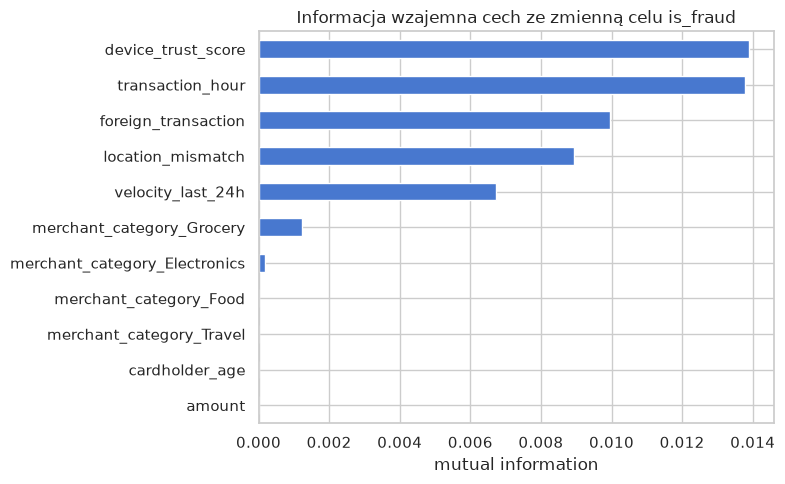

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
mi.sort_values().plot(kind="barh", ax=ax, color="#4878CF")
ax.set_title("Informacja wzajemna cech ze zmienną celu is_fraud")
ax.set_xlabel("mutual information")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_selekcja_cech_mi.png", dpi=120)
plt.show()

**Decyzja o selekcji cech:**
- **Usuwamy** `transaction_id` — czysty identyfikator, zero wartości predykcyjnej
  (a jego pozostawienie grozi przeuczeniem na sztucznym porządku wierszy).
- **Zostawiamy wszystkie pozostałe cechy.** Największy sygnał niosą
  `device_trust_score`, `location_mismatch`, `foreign_transaction`,
  `velocity_last_24h` i `amount`; słabsze cechy (`cardholder_age`, kategorie
  sprzedawcy) zostawiamy, bo zbiór jest mały (9 cech), a modele drzewiaste
  same zdecydują o ich użyciu — ostateczną weryfikacją będzie ważność cech
  w `03_model.ipynb`.

## 2. Kodowanie zmiennej `merchant_category` (DS24G2-12)

Zmienna nominalna bez naturalnego porządku (5 kategorii o zbliżonej liczności)
→ stosujemy **one-hot encoding** z `drop='first'`, żeby uniknąć współliniowości
w regresji logistycznej. W finalnym pipelinie użyjemy `OneHotEncoder`
ze scikit-learn (a nie `pd.get_dummies`), bo enkoder zapamiętuje kategorie
ze zbioru treningowego i identycznie koduje nowe dane.

In [4]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(drop="first", sparse_output=False)
encoded = enc.fit_transform(df[["merchant_category"]])
encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out())

print("Kategorie:", list(enc.categories_[0]))
print("Kolumny po zakodowaniu (drop='first' usuwa kategorię bazową Clothing... "
      "a dokładnie pierwszą alfabetycznie):")
encoded_df.head()

Kategorie: ['Clothing', 'Electronics', 'Food', 'Grocery', 'Travel']
Kolumny po zakodowaniu (drop='first' usuwa kategorię bazową Clothing... a dokładnie pierwszą alfabetycznie):


,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0


## 3. Transformacja zmiennej `transaction_hour` (DS24G2-13)

Godzina jest zmienną **cykliczną**: 23:00 i 0:00 dzieli godzina, a nie 23.
Traktowanie jej jako zwykłej liczby zaburza tę geometrię, dlatego kodujemy ją
na okręgu parą wartości sin/cos:

$$hour\_sin = \sin\left(\frac{2\pi h}{24}\right), \qquad
hour\_cos = \cos\left(\frac{2\pi h}{24}\right)$$

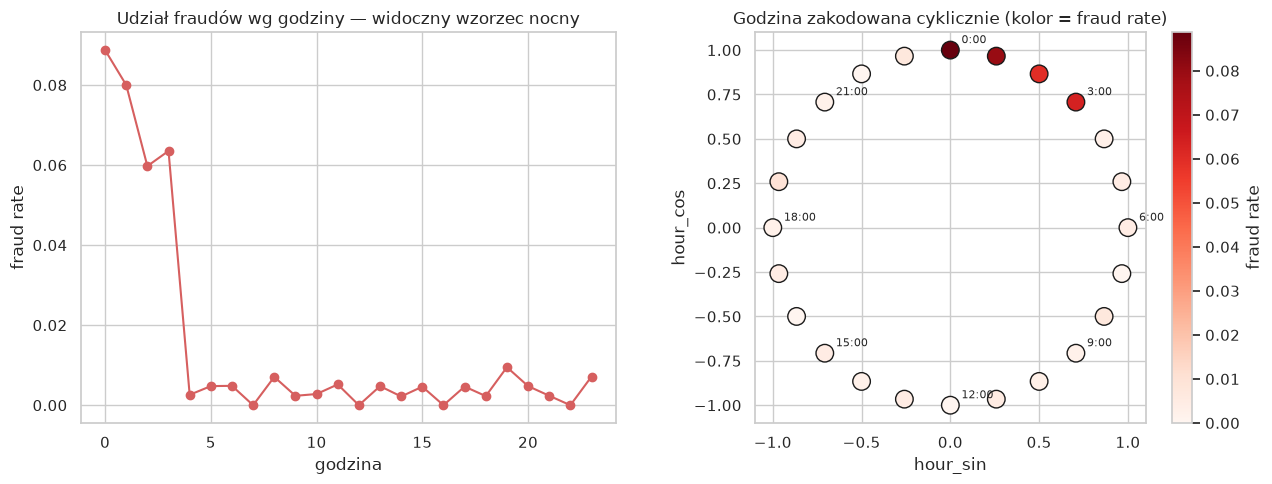

In [5]:
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)
fraud_by_hour = df.groupby("transaction_hour")["is_fraud"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fraud_by_hour.index, fraud_by_hour.values, "o-", color="#D65F5F")
ax1.set_xlabel("godzina"); ax1.set_ylabel("fraud rate")
ax1.set_title("Udział fraudów wg godziny — widoczny wzorzec nocny")

sc = ax2.scatter(hour_sin, hour_cos, c=fraud_by_hour.reindex(hours).values,
                 cmap="Reds", s=160, edgecolor="k")
for h in hours[::3]:
    ax2.annotate(f"{h}:00", (hour_sin[h], hour_cos[h]),
                 textcoords="offset points", xytext=(8, 5), fontsize=8)
ax2.set_xlabel("hour_sin"); ax2.set_ylabel("hour_cos")
ax2.set_title("Godzina zakodowana cyklicznie (kolor = fraud rate)")
ax2.set_aspect("equal")
plt.colorbar(sc, ax=ax2, label="fraud rate")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_transformacja_godziny.png", dpi=120)
plt.show()

Fraud rate jest wyraźnie podwyższony w godzinach nocnych (ok. 0–5), a kodowanie
sin/cos ustawia te godziny obok siebie na okręgu — model liniowy może teraz
nauczyć się „nocności" transakcji jako prostego kierunku w przestrzeni cech.

## 4. Przygotowanie danych do procesu uczenia (DS24G2-14)

Składamy wszystkie kroki w jeden `ColumnTransformer`:
- `merchant_category` → one-hot (`drop='first'`),
- `transaction_hour` → sin/cos (`FunctionTransformer`),
- pozostałe cechy liczbowe → standaryzacja (`StandardScaler`).

Transformer będzie **uczony wyłącznie na zbiorze treningowym** (wewnątrz
pipeline'u w `03_model.ipynb`), co eliminuje wyciek danych (data leakage).

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

def hour_to_sin_cos(X):
    h = np.asarray(X, dtype=float)
    return np.column_stack([np.sin(2 * np.pi * h[:, 0] / 24),
                            np.cos(2 * np.pi * h[:, 0] / 24)])

CAT_COLS = ["merchant_category"]
HOUR_COL = ["transaction_hour"]
NUM_COLS = ["amount", "foreign_transaction", "location_mismatch",
            "device_trust_score", "velocity_last_24h", "cardholder_age"]

def make_preprocess():
    return ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), CAT_COLS),
        ("hour", FunctionTransformer(
            hour_to_sin_cos,
            feature_names_out=lambda t, names: ["hour_sin", "hour_cos"]), HOUR_COL),
        ("num", StandardScaler(), NUM_COLS),
    ])

preprocess = make_preprocess()
sample = preprocess.fit_transform(df.drop(columns=["transaction_id", "is_fraud"]))
pd.DataFrame(sample, columns=preprocess.get_feature_names_out()).head()

,cat__merchant_category_Electronics,cat__merchant_category_Food,cat__merchant_category_Grocery,cat__merchant_category_Travel,hour__hour_sin,hour__hour_cos,num__amount,num__foreign_transaction,num__location_mismatch,num__device_trust_score,num__velocity_last_24h,num__cardholder_age
0,1.0,0.0,0.0,0.0,-0.500000,0.866025,-0.521597,-0.329244,-0.306158,0.195528,0.691873,-0.231580
1,0.0,0.0,0.0,1.0,0.707107,0.707107,2.086108,3.037260,-0.306158,1.172909,-0.704299,1.370727
2,0.0,0.0,1.0,0.0,-0.965926,-0.258819,0.348151,-0.329244,-0.306158,-0.595686,-0.704299,1.170439
3,0.0,0.0,1.0,0.0,0.866025,0.500000,-0.066254,-0.329244,3.266284,0.474779,0.691873,-0.632157
4,0.0,1.0,0.0,0.0,-0.707107,-0.707107,-0.829151,-0.329244,-0.306158,0.800573,-1.402386,0.035471


## 5. Podział na zbiory treningowy i testowy (DS24G2-15)

Podział 75/25 ze **stratyfikacją** po `is_fraud` — przy 1,5% fraudów zwykły
losowy podział mógłby zostawić w teście za mało (albo za dużo) przypadków
pozytywnych. Przetworzone zbiory zapisujemy do `data/processed/`
(katalog jest w `.gitignore` — pliki pozostają lokalnymi artefaktami).

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["transaction_id", "is_fraud"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

X_train.assign(is_fraud=y_train).to_csv("../data/processed/train.csv", index=False)
X_test.assign(is_fraud=y_test).to_csv("../data/processed/test.csv", index=False)

summary = pd.DataFrame({
    "wiersze": [len(X_train), len(X_test)],
    "fraudy": [y_train.sum(), y_test.sum()],
    "fraud rate": [f"{y_train.mean():.3%}", f"{y_test.mean():.3%}"],
}, index=["train", "test"])
summary

,wiersze,fraudy,fraud rate
train,7500,113,1.507%
test,2500,38,1.520%


## Podsumowanie Sprintu 2 (część przygotowania danych)

| Zadanie | Rezultat |
|---|---|
| DS24G2-11 | usunięte `transaction_id`; pozostałe cechy zostają (ranking MI + korelacje) |
| DS24G2-12 | `merchant_category` → one-hot z `drop='first'` |
| DS24G2-13 | `transaction_hour` → cykliczne kodowanie sin/cos |
| DS24G2-14 | jeden `ColumnTransformer` (one-hot + sin/cos + standaryzacja), bez wycieku danych |
| DS24G2-15 | stratyfikowany podział 75/25, identyczny fraud rate w train i test |

Trenowanie, strojenie i obsługa niezbalansowania: `03_model.ipynb`.